# Calcium Aluminosilicate Glass Simulation with Pedone PMMCS Potential
This notebook is designed to showcase the implementations of the pyiron_glass package for simulating multi-component glasses with classical interatomic potentials.
It will be further extended to include more complex simulations and analyses.


## Potential and Elements
Simulations implemented so far are based on the PMMCS interatomic potential from A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018.
The PMMCS potential makes use of 2-body MORSE interactions between oxygen and cations, electrostatic interactions based on scaled partial charges (i.e., O=-1.2, Na=0.6, Mg=1.2, Al=1.8) among all ions, and a repulsive short-range term. It was originally fitted to reproduce the experimental crystal structures and elastic constants of oxides, silicates, and aluminosilicates.

The supported elements in alphabetical order are:

Ag, Al, Ba, Be, Ca, Co, Cr, Cu, Er, Fe, Fe3, Gd, Ge, K, Li, Mg, Mn, Na, Nd, Ni, O, P, Sc, Si, Sn, Sr, Ti, Zn, Zr

The cations can be classified into three categories:
- Alkali: Li, Na, K
- Alkaline Earth: Be, Mg, Ca, Sr, Ba
- Transition/Other: Fe, Zn, Al, Ti, Zr, etc.

Typical compositions the potential can handle include:
- Silicate-based systems: SiO2, Al2O3-SiO2, Na2O-SiO2, etc.
- Phosphate-based systems: P2O5 with modifiers (Ca, Mg, Zn, etc.)
- Mixed network formers: SiO2-P2O5-Al2O3 systems


## Standard Melt-Quenching Protocol and Parameters
Simulation settings employed in the following simulations do not represent production run conditions and are rather for demonstration purposes. They can be adjusted based on the specific requirements of your simulation. The simulation workflow consists of the following steps:

0. Random structure generation based on composition, number of atoms and density. For fast simulations, a small number of atoms (e.g., 200) is used.
1. NVT: heating from 300 to 5000 K with a constant heating rate (here: on the order of 1-10 K/ps)
2. NVT: equilibration of the melt at 5000 K for 100 ps (NVT ensemble)
3. NVT: cooling with down to 300 K (again with 1-10 K/ps)
4. NpT: equilibration at 300 K to relax the stress
5. NVT: extended equilibration at 300 K to extract thermodynamic and structural properties

Typical simulation parameters are applied: lammps metal units, periodic boundary conditions, timestep of 1-2 fs. Other default parameters are hidden in the underlying lammps functions, such as temperature damping of 100 time units and pressure damping of 1000 time units. If desired, Langevin thermostat and barostat can be used by setting the corresponding options.


# Import of packages

In [2]:
from pyiron_base import Project

from pyiron_glass import (
    melt_quench_simulation,
    generate_potential,
    get_ase_structure,
    get_structure_dict,
)
from pyiron_glass.workflows.structural_analysis import (
    analyze_structure,
    plot_analysis_results_plotly,
)

# Example Melt-Quenching Simulation

In [3]:
# Definition of the pyiron project,
# generating an initial random structure
# and setting up the potential information
pr = Project("glass")
atoms_dict = get_structure_dict(
    composition="25CaO-25Al2O3-50SiO2",  #    comp = "20.2CaO-36.6Al2O3-43.2SiO2" this is in weight%,
    n_molecules=None,
    target_atoms=1010,
    mode="molar",  # mode = "weight",
    density=None,
    min_distance=1.8,
    max_attempts_per_atom=10000,
    pyiron_project=pr,
)
structure = get_ase_structure(
    atoms_dict=atoms_dict,
    replicate=(1, 1, 1),
    pyiron_project=pr,
)
generated_potential = generate_potential(
    atoms_dict=atoms_dict,
    pyiron_project=pr,
)

In [4]:
# Specification of the cpu parameters
ncpus = 4
server_kwargs = {"cores": ncpus}

# Specification of the melt-quenching parameters
delayed = melt_quench_simulation(
    structure=structure,
    potential=generated_potential,
    temperature_high=5000,
    temperature_low=300,
    n_print=1000,
    heating_rate=int(1e14),
    cooling_rate=int(1e14),
    langevin=False,
    server_kwargs=server_kwargs,
    pyiron_project=pr,
)

# Set server settings
# delayed.server.queue = "big"
# delayed.server.cores = ncpus
# delayed.server.run_time = 1440

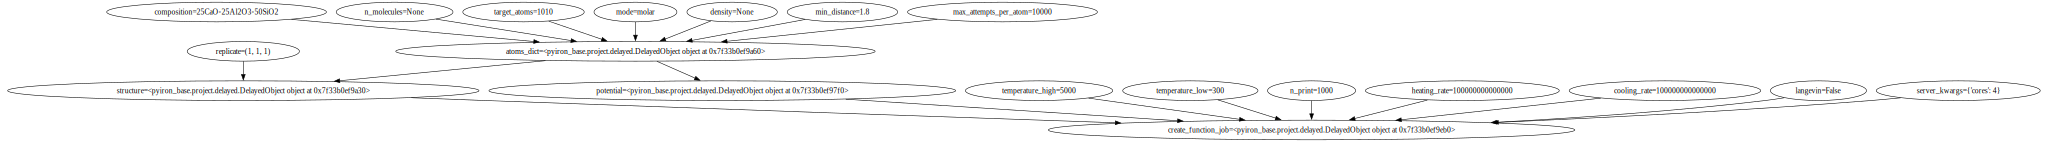

In [5]:
delayed.draw()

In [6]:
# Run the simulation and retrieve the results. Takes 5-10 minutes with the default testing parameters.
result = delayed.pull()

The job get_structure_dict_04f6f6855e6e47f62195aa8001e12dca was saved and received the ID: 18
The job get_ase_structure_d43821a8627cacdc35edf91630927af4 was saved and received the ID: 19
The job generate_potential_740aed8f1e10c7a6707220cbd9fadcde was saved and received the ID: 20


/net/fileserver1/data_raid/platte2/LINUX_HOMES/leo/miniforge3/envs/pyiron-glass/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(fname, key=rootpath)
/net/fileserver1/data_raid/platte2/LINUX_HOMES/leo/miniforge3/envs/pyiron-glass/lib/python3.12/site-packages/h5io/_h5io.py:72: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(file_name, key=rootpath)
/net/fileserver1/data_raid/platte2/LINUX_HOMES/leo/miniforge3/envs/pyiron-glass/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may s

The job melt_quench_simulation_d39d65a1ec814d1122ef2051c4a43076 was saved and received the ID: 21


/net/fileserver1/data_raid/platte2/LINUX_HOMES/leo/miniforge3/envs/pyiron-glass/lib/python3.12/site-packages/h5io/_h5io.py:72: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(file_name, key=rootpath)
/net/fileserver1/data_raid/platte2/LINUX_HOMES/leo/miniforge3/envs/pyiron-glass/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(fname, key=rootpath)


In [7]:
structure_glass = result["structure"]
structure_glass

Atoms(symbols='Al156Ca78O622Si155', pbc=True, cell=[[23.2662703802071, 4.2739445323826236e-15, 4.2739445323826236e-15], [-2.8492963548963865e-15, 23.26627038, 4.273944532344581e-15], [-2.8492963548963865e-15, -2.8492963548963877e-15, 23.26627038]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)

In [8]:
results_analysis = analyze_structure(atoms=structure_glass, pyiron_project=pr).pull()

The job analyze_structure_4f2aec3bf71e13482c5b25e1de5915d2 was saved and received the ID: 22


100%|██████████| 1251/1251 [00:00<00:00, 3838.06it/s]


In [9]:
fig = plot_analysis_results_plotly(results_analysis)
fig.show()

In [11]:
# Explore the structured analysis results
print("=== Structural Analysis Results ===")
print(f"Density: {results_analysis.density:.2f} g/cm³")

print("\n=== Coordination Information ===")
if results_analysis.coordination.oxygen:
    print("Oxygen coordination:", results_analysis.coordination.oxygen)

print("\n=== Network Information ===")
print(f"Network connectivity: {results_analysis.network.connectivity:.3f}")
if results_analysis.network.Qn_distribution:
    print("Q^n distribution:", results_analysis.network.Qn_distribution)

print("\n=== Element Classification ===")
print("Network formers:", results_analysis.elements.formers)
print("Modifiers:", results_analysis.elements.modifiers)
print("Cutoff distances:", results_analysis.elements.cutoffs)

=== Structural Analysis Results ===
Density: 2.85 g/cm³

=== Coordination Information ===
Oxygen coordination: {'1': 72, '2': 471, '3': 78, '4': 1}

=== Network Information ===
Network connectivity: 3.794
Q^n distribution: {'0': 0.0, '1': 0.0, '2': 7.0, '3': 58.0, '4': 238.0, '5': 8.0, '6': 0.0}

=== Element Classification ===
Network formers: ['Si', 'Al']
Modifiers: ['Ca']
Cutoff distances: {'O': 2.1175, 'Al': 2.1175, 'Si': 1.8375, 'Ca': 2.5875}
